# Data Exploration

In [2]:
# Enable auto-reload for development
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
import os

sys.path.append(os.path.abspath("../../scripts"))

import plots


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
df = pd.read_csv('../../data/04-03-24/A1.csv')
if "#NAME?" in df.columns: df = df.rename(columns={"#NAME?": "Im(Z)/Ohm"})

df.columns.values

array(['mode', 'ox/red', 'error', 'control changes', 'Ns changes',
       'counter inc.', 'Ns', 'I Range', 'time/s', 'control/V/mA',
       'Ecell/V', 'I/mA', 'dq/mA.h', '(Q-Qo)/mA.h', '|Energy|/W.h',
       'freq/Hz', '|Z|/Ohm', 'Phase(Z)/deg', 'Q charge/discharge/mA.h',
       'half cycle', 'Energy charge/W.h', 'Energy discharge/W.h',
       'Capacitance charge/µF', 'Capacitance discharge/µF', 'step time/s',
       'z cycle', 'Re(Z)/Ohm', 'Im(Z)/Ohm', 'Re(Y)/Ohm-1', 'Im(Y)/Ohm-1',
       '|Y|/Ohm-1', 'Phase(Y)/deg', 'x', 'Q discharge/mA.h',
       'Q charge/mA.h', 'Capacity/mA.h', 'Efficiency/%', 'control/V',
       'control/mA', 'cycle number', 'P/W', 'R/Ohm'], dtype=object)

## Unique Frequency count per cycle

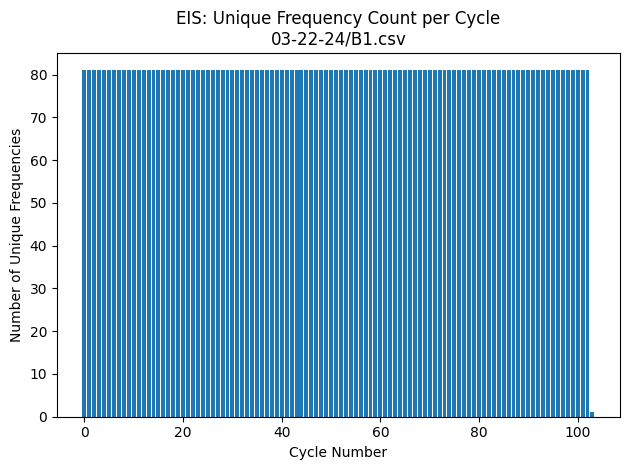

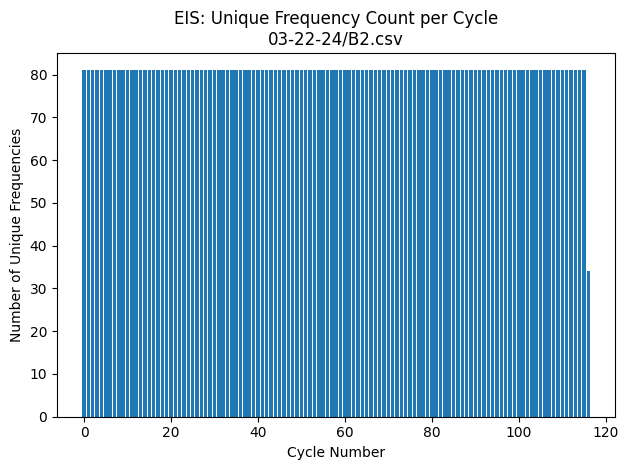

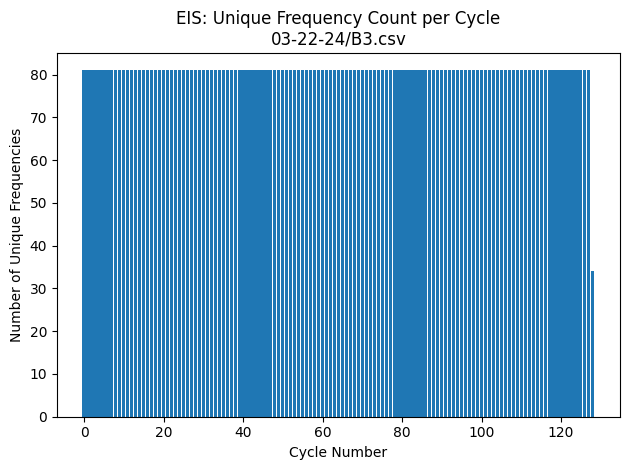

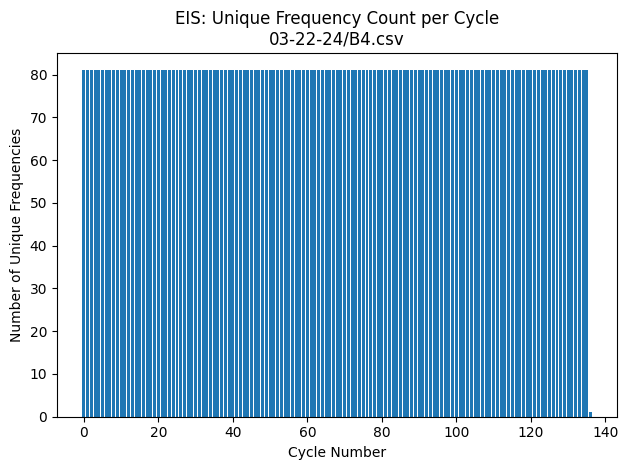

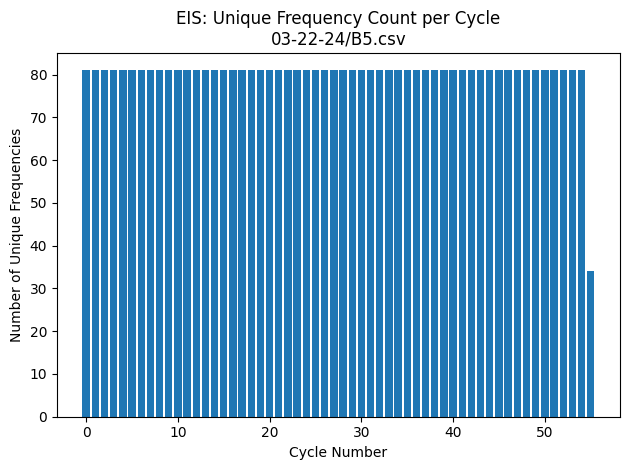

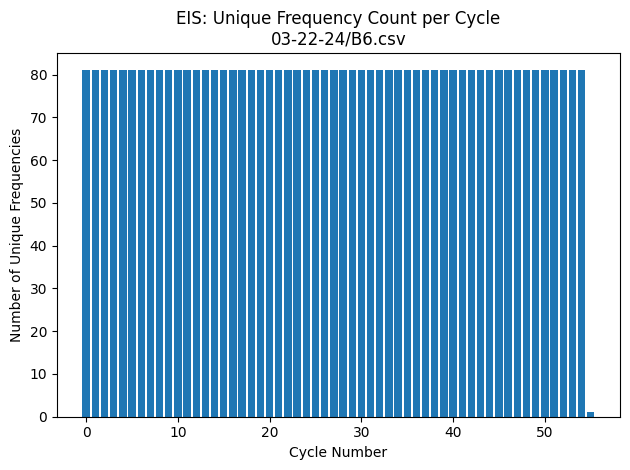

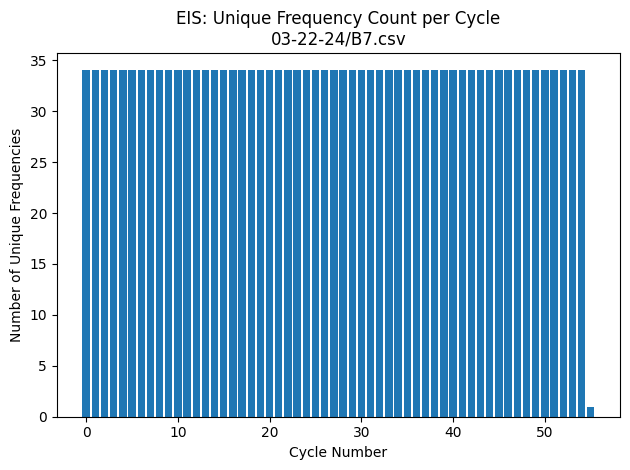

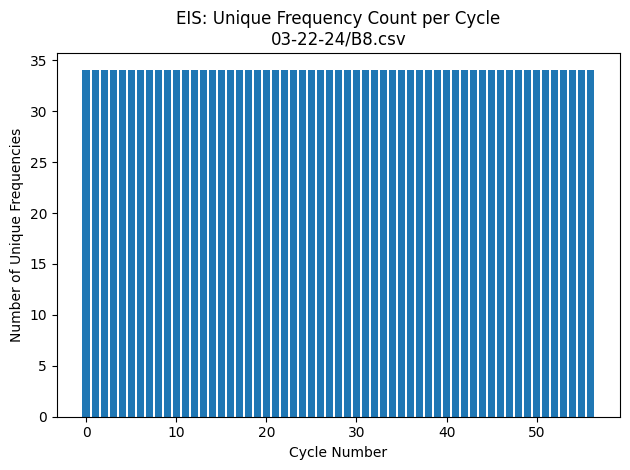

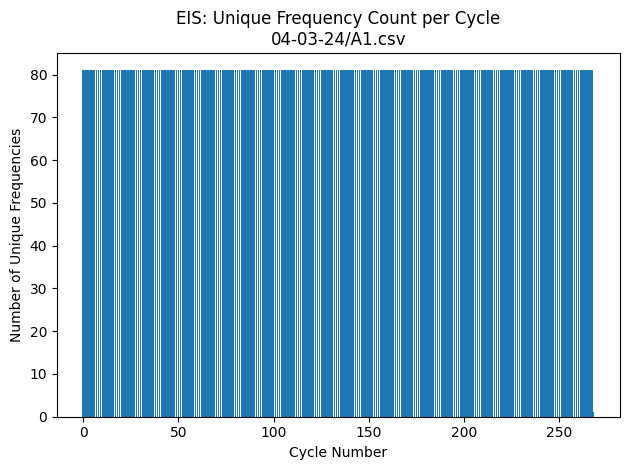

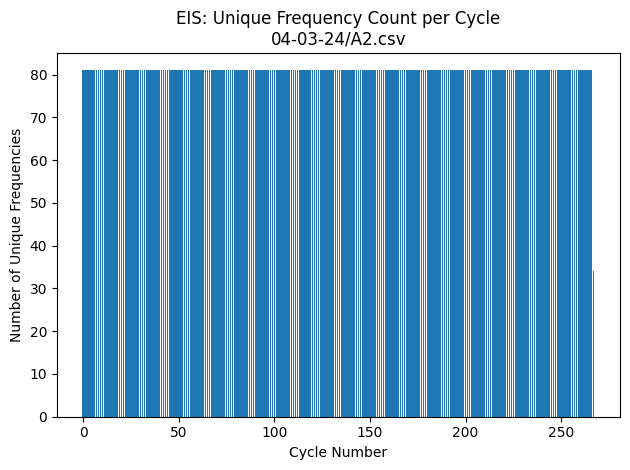

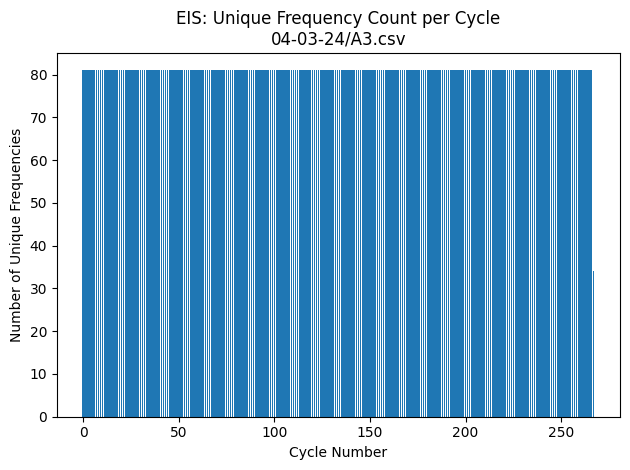

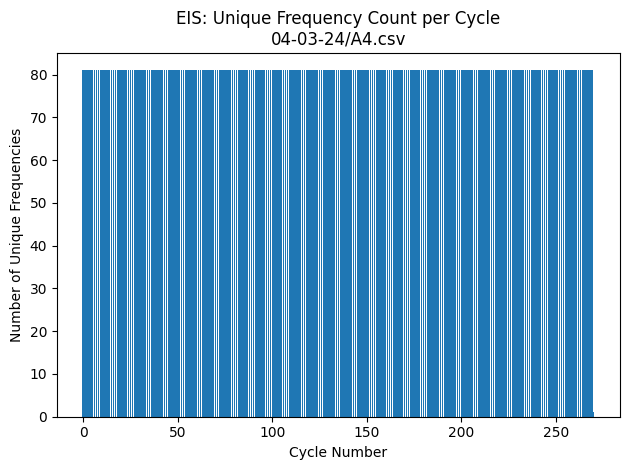

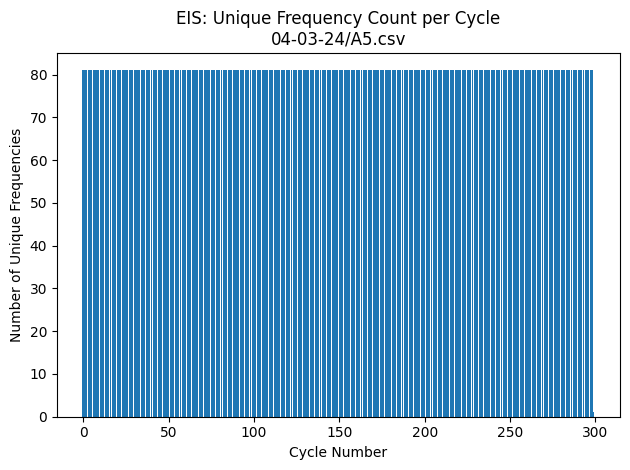

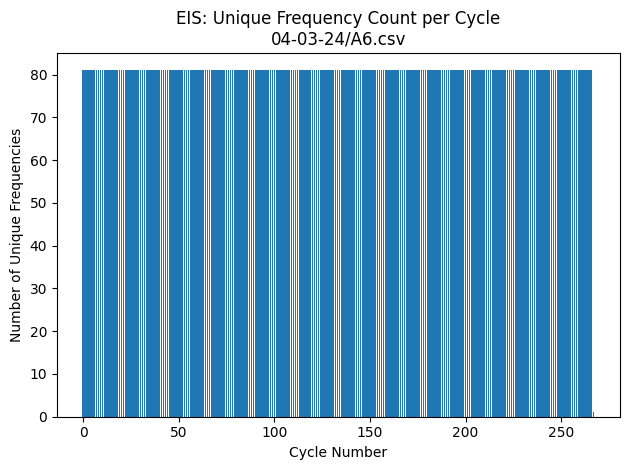

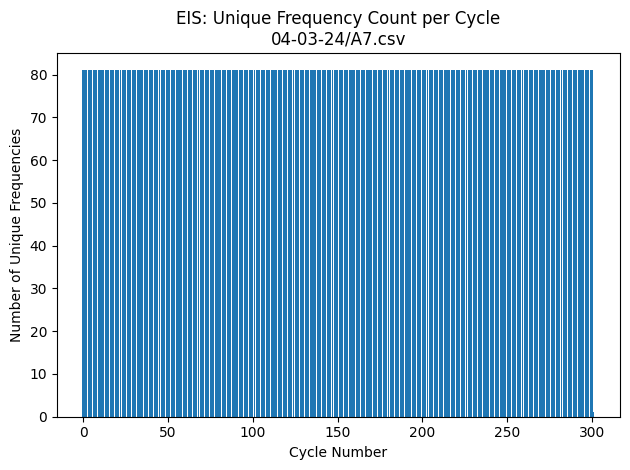

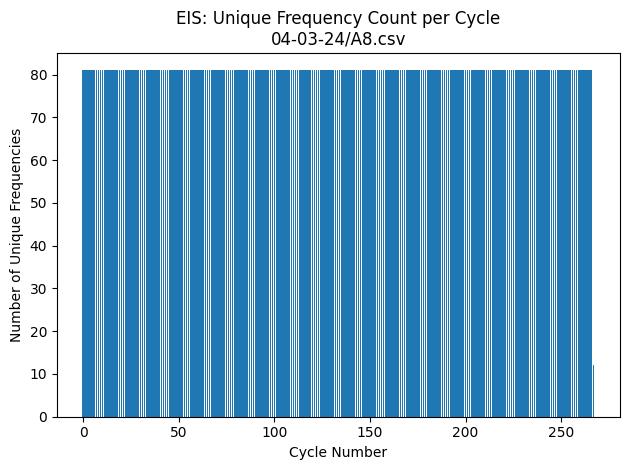

In [5]:
# Adjust this to point at the parent folder that contains your date-folders
data_root = "../../data"

for folder in sorted(os.listdir(data_root)):
    folder_path = os.path.join(data_root, folder)
    if not os.path.isdir(folder_path):
        continue

    for filename in sorted(os.listdir(folder_path)):
        if not filename.lower().endswith('.csv'):
            continue

        # 1) Load
        df = pd.read_csv(f'{data_root}/{folder}/{filename}')

        # 2) Compute unique-frequency count per cycle
        freq_counts = (
            df
            .groupby('cycle number')['freq/Hz']
            .nunique()
            .reset_index(name='unique_freq_count')
        )

        # 3) Plot
        plt.figure()
        plt.bar(freq_counts['cycle number'], freq_counts['unique_freq_count'])
        plt.xlabel('Cycle Number')
        plt.ylabel('Number of Unique Frequencies')
        plt.title(f'EIS: Unique Frequency Count per Cycle\n{folder}/{filename}')
        plt.tight_layout()
        plt.show()


## Preprocess for exploration

In [11]:
df = pd.read_csv('../data/04-03-24/A1.csv')
df = df[(df['freq/Hz'] > 0.2) & (df['freq/Hz'] <= 20000)]
unique_freqs = np.array(df['freq/Hz'].unique())
unique_freqs.sort()

print(unique_freqs)

[2.54e-01 3.40e-01 4.56e-01 6.12e-01 8.22e-01 9.99e-01 1.10e+00 1.33e+00
 1.48e+00 1.78e+00 1.99e+00 2.37e+00 2.66e+00 3.16e+00 3.57e+00 4.22e+00
 4.80e+00 5.62e+00 6.43e+00 7.50e+00 8.64e+00 1.00e+01 1.16e+01 1.33e+01
 1.55e+01 1.78e+01 2.09e+01 2.37e+01 2.80e+01 3.16e+01 3.75e+01 4.22e+01
 5.03e+01 5.62e+01 6.76e+01 7.50e+01 9.06e+01 1.02e+02 1.22e+02 1.35e+02
 1.63e+02 1.78e+02 2.19e+02 2.37e+02 2.94e+02 3.16e+02 3.94e+02 4.22e+02
 5.29e+02 5.64e+02 7.10e+02 7.50e+02 9.52e+02 1.00e+03 1.28e+03 1.33e+03
 1.71e+03 1.78e+03 2.30e+03 2.37e+03 3.09e+03 3.16e+03 4.14e+03 4.22e+03
 5.56e+03 5.62e+03 7.45e+03 7.50e+03 1.00e+04]


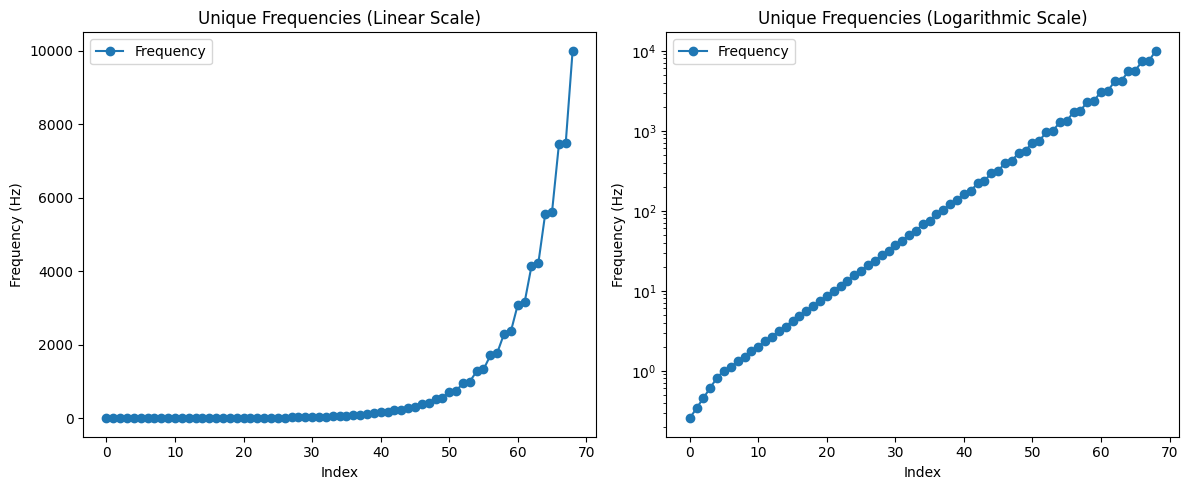

In [12]:
plots.unique_frequencies(unique_freqs)